# EDA - Fraud_Data.csv (E-commerce Transactions)

## Objective
Comprehensive exploratory data analysis and preprocessing of e-commerce fraud data, including:
- Data cleaning (missing values, duplicates, data types)
- Univariate and bivariate analysis
- Class imbalance quantification
- Geolocation integration (IP to country mapping)
- Initial feature engineering

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Data Loading and Initial Exploration

In [45]:
# Load datasets
fraud_data = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_country = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print("Fraud Data shape:", fraud_data.shape)
print("\nFirst few rows:")
print(fraud_data.head())
print("\nData Info:")
print(fraud_data.info())

Fraud Data shape: (151112, 11)

First few rows:
   user_id          signup_time        purchase_time  purchase_value  \
0    22058  2015-02-24 22:55:49  2015-04-18 02:47:11              34   
1   333320  2015-06-07 20:39:50  2015-06-08 01:38:54              16   
2     1359  2015-01-01 18:52:44  2015-01-01 18:52:45              15   
3   150084  2015-04-28 21:13:25  2015-05-04 13:54:50              44   
4   221365  2015-07-21 07:09:52  2015-09-09 18:40:53              39   

       device_id source browser sex  age    ip_address  class  
0  QVPSPJUOCKZAR    SEO  Chrome   M   39  7.327584e+08      0  
1  EOGFQPIZPYXFZ    Ads  Chrome   F   53  3.503114e+08      0  
2  YSSKYOSJHPPLJ    SEO   Opera   M   53  2.621474e+09      1  
3  ATGTXKYKUDUQN    SEO  Safari   M   41  3.840542e+09      0  
4  NAUITBZFJKHWW    Ads  Safari   M   45  4.155831e+08      0  

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          No

In [46]:
print("\nIP to Country Data shape:", ip_country.shape)
print("\nFirst few rows:")
print(ip_country.head())
print("\nData Info:")
print(ip_country.info())


IP to Country Data shape: (138846, 3)

First few rows:
   lower_bound_ip_address  upper_bound_ip_address    country
0              16777216.0                16777471  Australia
1              16777472.0                16777727      China
2              16777728.0                16778239      China
3              16778240.0                16779263  Australia
4              16779264.0                16781311      China

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   lower_bound_ip_address  138846 non-null  float64
 1   upper_bound_ip_address  138846 non-null  int64  
 2   country                 138846 non-null  str    
dtypes: float64(1), int64(1), str(1)
memory usage: 3.2 MB
None


## 2. Data Cleaning

In [47]:
# Check for missing values
print("Missing values:")
missing = fraud_data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

print("\nMissing values percentage:")
missing_pct = (fraud_data.isnull().sum() / len(fraud_data)) * 100
print(missing_pct[missing_pct > 0] if missing_pct.sum() > 0 else "No missing values")

Missing values:
No missing values

Missing values percentage:
No missing values


In [48]:
# Check for duplicates
print(f"Total rows: {len(fraud_data)}")
print(f"Duplicate rows: {fraud_data.duplicated().sum()}")

# Check for duplicates based on key identifiers
print(f"\nDuplicate transactions (same user, device, timestamp): {fraud_data.duplicated(subset=['user_id', 'device_id', 'purchase_time']).sum()}")

Total rows: 151112
Duplicate rows: 0

Duplicate transactions (same user, device, timestamp): 0


In [49]:
# Remove duplicates if any
fraud_data_clean = fraud_data.drop_duplicates()
print(f"Rows after removing duplicates: {len(fraud_data_clean)}")
print(f"Rows removed: {len(fraud_data) - len(fraud_data_clean)}")

Rows after removing duplicates: 151112
Rows removed: 0


In [50]:
# Data type corrections
print("Current data types:")
print(fraud_data_clean.dtypes)

# Convert timestamp columns to datetime
fraud_data_clean['signup_time'] = pd.to_datetime(fraud_data_clean['signup_time'])
fraud_data_clean['purchase_time'] = pd.to_datetime(fraud_data_clean['purchase_time'])

# Convert categorical columns
fraud_data_clean['sex'] = fraud_data_clean['sex'].astype('category')
fraud_data_clean['class'] = fraud_data_clean['class'].astype('int8')

print("\nUpdated data types:")
print(fraud_data_clean.dtypes)

Current data types:
user_id             int64
signup_time           str
purchase_time         str
purchase_value      int64
device_id             str
source                str
browser               str
sex                   str
age                 int64
ip_address        float64
class               int64
dtype: object

Updated data types:
user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                     category
age                        int64
ip_address               float64
class                       int8
dtype: object


## 3. Exploratory Data Analysis - Univariate Analysis

In [51]:
# Basic statistics
print("Numerical Features Statistics:")
print(fraud_data_clean.describe())

Numerical Features Statistics:
             user_id                 signup_time               purchase_time  \
count  151112.000000                      151112                      151112   
mean   200171.040970  2015-04-20 00:56:09.511329  2015-06-16 02:56:38.759952   
min         2.000000         2015-01-01 00:00:42         2015-01-01 00:00:44   
25%    100642.500000  2015-02-18 09:52:48.500000  2015-04-18 14:41:25.500000   
50%    199958.000000         2015-04-19 04:41:30  2015-06-18 13:46:17.500000   
75%    300054.000000  2015-06-18 14:47:22.750000  2015-08-17 18:48:31.500000   
max    400000.000000         2015-08-18 04:40:29         2015-12-16 02:56:05   
std    115369.285024                         NaN                         NaN   

       purchase_value            age    ip_address          class  
count   151112.000000  151112.000000  1.511120e+05  151112.000000  
mean        36.935372      33.140704  2.152145e+09       0.093646  
min          9.000000      18.000000  5.2093

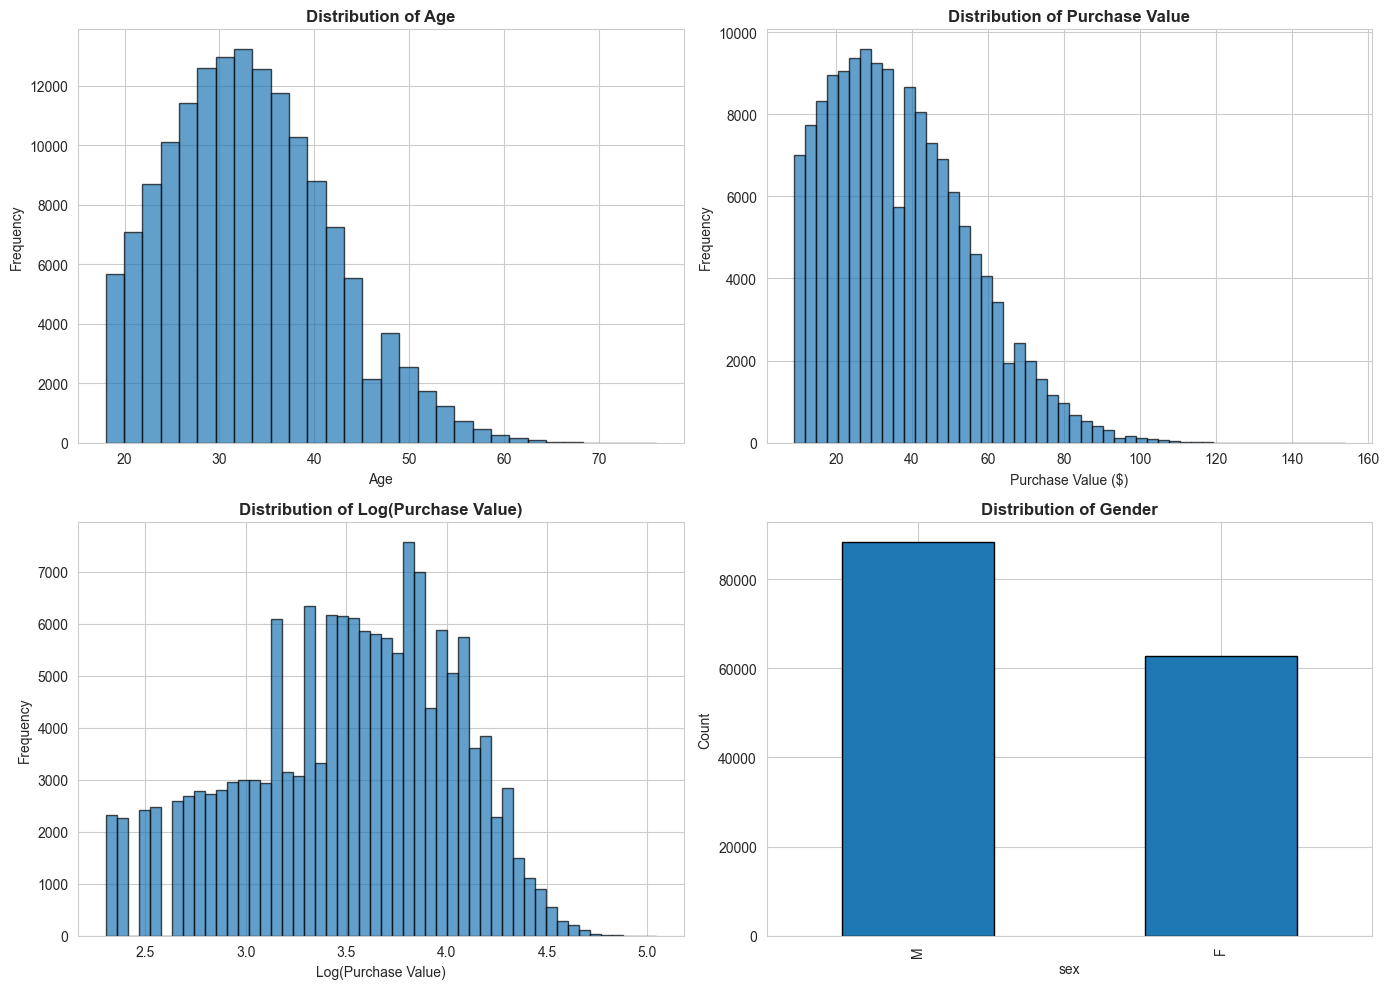

In [52]:
# Distribution of age
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
axes[0, 0].hist(fraud_data_clean['age'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Age', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Purchase value distribution
axes[0, 1].hist(fraud_data_clean['purchase_value'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Purchase Value', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Purchase Value ($)')
axes[0, 1].set_ylabel('Frequency')

# Log-scaled purchase value
axes[1, 0].hist(np.log1p(fraud_data_clean['purchase_value']), bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Log(Purchase Value)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Log(Purchase Value)')
axes[1, 0].set_ylabel('Frequency')

# Categorical distributions
fraud_data_clean['sex'].value_counts().plot(kind='bar', ax=axes[1, 1], edgecolor='black')
axes[1, 1].set_title('Distribution of Gender', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/processed/univariate_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [53]:
# Categorical features analysis
print("\nUnique values in categorical columns:")
print(f"Unique users: {fraud_data_clean['user_id'].nunique()}")
print(f"Unique devices: {fraud_data_clean['device_id'].nunique()}")
print(f"Unique browsers: {fraud_data_clean['browser'].nunique()}")
print(f"Unique sources: {fraud_data_clean['source'].nunique()}")
print(f"Unique IP addresses: {fraud_data_clean['ip_address'].nunique()}")

print("\nBrowser distribution:")
print(fraud_data_clean['browser'].value_counts().head(10))

print("\nSource distribution:")
print(fraud_data_clean['source'].value_counts())


Unique values in categorical columns:
Unique users: 151112
Unique devices: 137956
Unique browsers: 5
Unique sources: 3
Unique IP addresses: 143512

Browser distribution:
browser
Chrome     61432
IE         36727
Safari     24667
FireFox    24610
Opera       3676
Name: count, dtype: int64

Source distribution:
source
SEO       60615
Ads       59881
Direct    30616
Name: count, dtype: int64


## 4. Class Imbalance Analysis

Class Distribution:
Legitimate (0): 136961 (90.64%)
Fraudulent (1): 14151 (9.36%)

Imbalance Ratio: 9.68:1


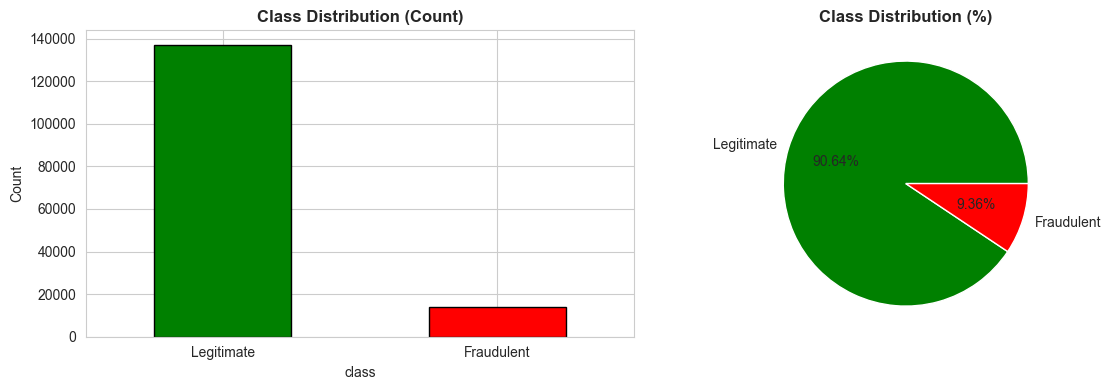

In [54]:
# Class distribution
class_counts = fraud_data_clean['class'].value_counts()
class_pct = fraud_data_clean['class'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"Legitimate (0): {class_counts[0]} ({class_pct[0]:.2f}%)")
print(f"Fraudulent (1): {class_counts[1]} ({class_pct[1]:.2f}%)")
print(f"\nImbalance Ratio: {class_counts[0] / class_counts[1]:.2f}:1")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts.plot(kind='bar', ax=axes[0], edgecolor='black', color=['green', 'red'])
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)

class_pct.plot(kind='pie', ax=axes[1], labels=['Legitimate', 'Fraudulent'], autopct='%1.2f%%', colors=['green', 'red'])
axes[1].set_title('Class Distribution (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../data/processed/class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Bivariate Analysis - Features vs Target

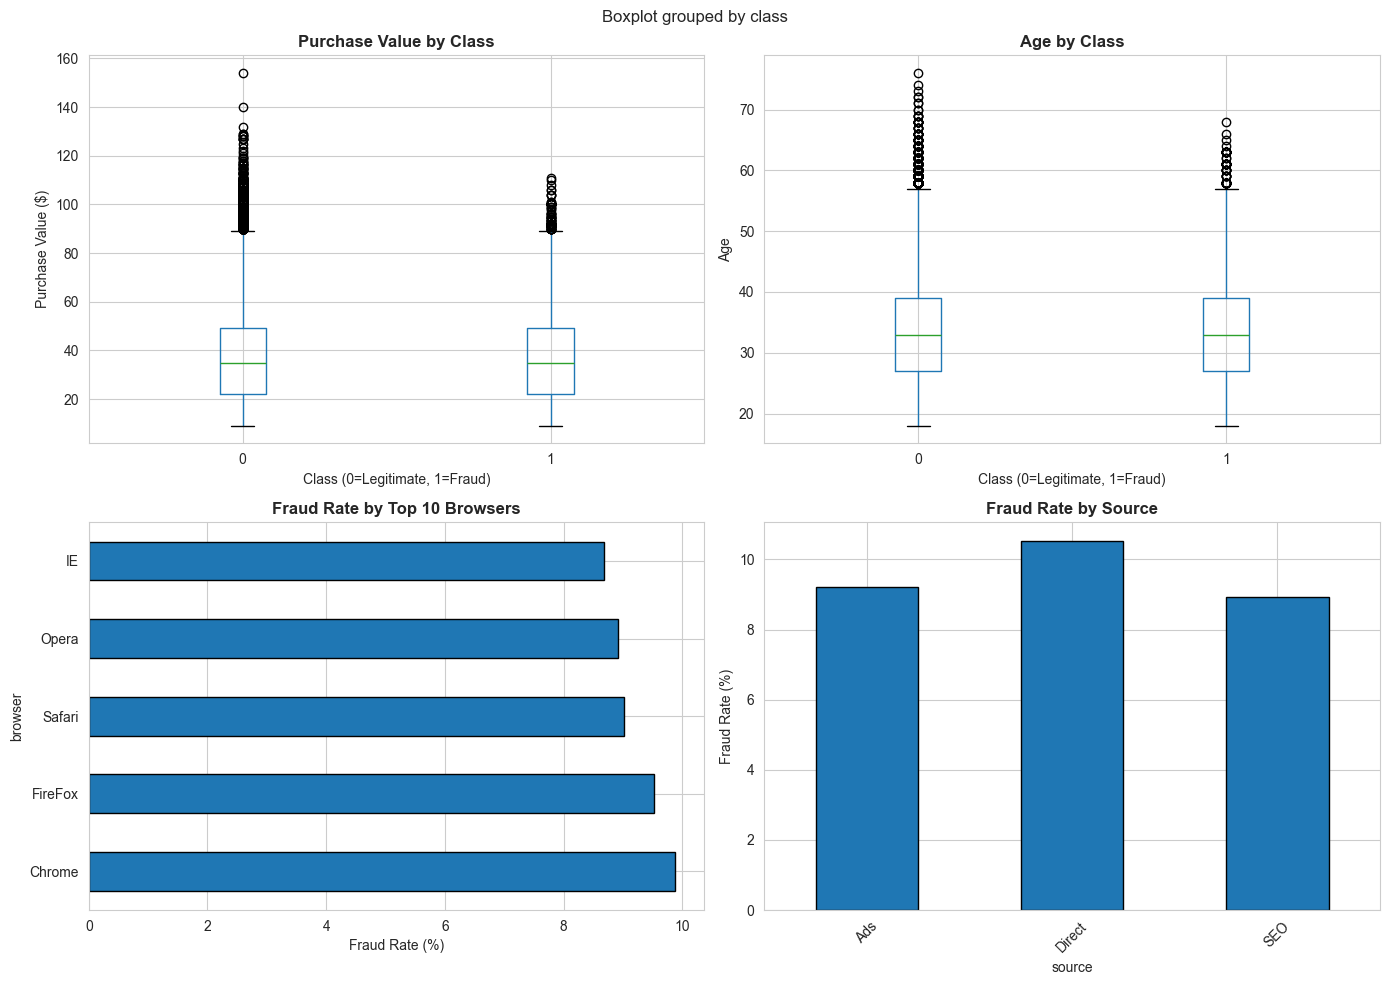

In [55]:
# Purchase value by class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Box plot - Purchase value by class
fraud_data_clean.boxplot(column='purchase_value', by='class', ax=axes[0, 0])
axes[0, 0].set_title('Purchase Value by Class', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0, 0].set_ylabel('Purchase Value ($)')

# Box plot - Age by class
fraud_data_clean.boxplot(column='age', by='class', ax=axes[0, 1])
axes[0, 1].set_title('Age by Class', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0, 1].set_ylabel('Age')

# Browser vs Class
browser_class = pd.crosstab(fraud_data_clean['browser'], fraud_data_clean['class'])
browser_class_fraud_rate = browser_class[1] / (browser_class[0] + browser_class[1]) * 100
browser_class_fraud_rate.sort_values(ascending=False).head(10).plot(kind='barh', ax=axes[1, 0], edgecolor='black')
axes[1, 0].set_title('Fraud Rate by Top 10 Browsers', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Fraud Rate (%)')

# Source vs Class
source_class = pd.crosstab(fraud_data_clean['source'], fraud_data_clean['class'])
source_class_fraud_rate = source_class[1] / (source_class[0] + source_class[1]) * 100
source_class_fraud_rate.plot(kind='bar', ax=axes[1, 1], edgecolor='black')
axes[1, 1].set_title('Fraud Rate by Source', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Fraud Rate (%)')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/bivariate_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [56]:
# Gender vs Class
sex_class = pd.crosstab(fraud_data_clean['sex'], fraud_data_clean['class'])
sex_class_fraud_rate = sex_class[1] / (sex_class[0] + sex_class[1]) * 100

print("\nFraud Rate by Gender:")
print(sex_class_fraud_rate)

print("\nFraud Rate by Source:")
print(source_class_fraud_rate)

print("\nFraud Rate by Top Browsers:")
print(browser_class_fraud_rate.sort_values(ascending=False).head(10))


Fraud Rate by Gender:
sex
F    9.100750
M    9.552286
dtype: float64

Fraud Rate by Source:
source
Ads        9.206593
Direct    10.536974
SEO        8.928483
dtype: float64

Fraud Rate by Top Browsers:
browser
Chrome     9.879216
FireFox    9.516457
Safari     9.020148
Opera      8.922742
IE         8.677540
dtype: float64


## 6. Geolocation Integration - IP Address Processing

In [57]:
# Function to convert IP address to integer
def ip_to_int(ip_str):
    """Convert IP address string to integer, handle NaN values"""
    if pd.isna(ip_str):
        return np.nan
    try:
        parts = str(ip_str).split('.')
        if len(parts) != 4:
            return np.nan
        return (int(parts[0]) << 24) + (int(parts[1]) << 16) + (int(parts[2]) << 8) + int(parts[3])
    except (ValueError, AttributeError):
        return np.nan

# Test the function
test_ip = fraud_data_clean['ip_address'].iloc[0]
print(f"Test IP: {test_ip}")
print(f"IP as integer: {ip_to_int(test_ip)}")
print(f"Test with NaN: {ip_to_int(np.nan)}")

Test IP: 732758368.79972
IP as integer: nan
Test with NaN: nan


In [58]:
# Convert IP addresses to integers
print("Converting IP addresses to integers...")
fraud_data_clean['ip_address_int'] = fraud_data_clean['ip_address'].apply(ip_to_int)
print("Conversion complete!")

# Check for failed conversions
failed_conversions = fraud_data_clean['ip_address_int'].isna().sum()
print(f"Failed conversions (NaN IP addresses): {failed_conversions}")

print("\nSample of converted IPs:")
print(fraud_data_clean[['ip_address', 'ip_address_int']].head(10))

Converting IP addresses to integers...
Conversion complete!
Failed conversions (NaN IP addresses): 151112

Sample of converted IPs:
     ip_address  ip_address_int
0  7.327584e+08             NaN
1  3.503114e+08             NaN
2  2.621474e+09             NaN
3  3.840542e+09             NaN
4  4.155831e+08             NaN
5  2.809315e+09             NaN
6  3.987484e+09             NaN
7  1.692459e+09             NaN
8  3.719094e+09             NaN
9  3.416747e+08             NaN


In [59]:
# Convert IP country data to integers
print("Converting IP ranges to integers...")
ip_country['lower_bound_ip_int'] = ip_country['lower_bound_ip_address'].apply(ip_to_int)
ip_country['upper_bound_ip_int'] = ip_country['upper_bound_ip_address'].apply(ip_to_int)
print("Conversion complete!")

print("\nIP Country data sample:")
print(ip_country.head(10))

Converting IP ranges to integers...
Conversion complete!

IP Country data sample:
   lower_bound_ip_address  upper_bound_ip_address    country  \
0              16777216.0                16777471  Australia   
1              16777472.0                16777727      China   
2              16777728.0                16778239      China   
3              16778240.0                16779263  Australia   
4              16779264.0                16781311      China   
5              16781312.0                16785407      Japan   
6              16785408.0                16793599      China   
7              16793600.0                16809983      Japan   
8              16809984.0                16842751   Thailand   
9              16842752.0                16843007      China   

   lower_bound_ip_int  upper_bound_ip_int  
0                 NaN                 NaN  
1                 NaN                 NaN  
2                 NaN                 NaN  
3                 NaN                

In [60]:
# Range-based IP-to-country lookup using merge_asof
print("Performing range-based IP lookup...")

# Drop rows with invalid IP addresses (NaN) before merging
fraud_data_valid = fraud_data_clean.dropna(subset=['ip_address_int']).copy()
print(f"Records with valid IPs: {len(fraud_data_valid)} (removed {len(fraud_data_clean) - len(fraud_data_valid)})")

# Sort both dataframes by IP ranges
fraud_data_sorted = fraud_data_valid.sort_values('ip_address_int').reset_index(drop=True)
ip_country_sorted = ip_country.sort_values('lower_bound_ip_int').reset_index(drop=True)

# Use merge_asof for range lookup
fraud_with_country = pd.merge_asof(
    fraud_data_sorted,
    ip_country_sorted[['lower_bound_ip_int', 'upper_bound_ip_int', 'country']],
    left_on='ip_address_int',
    right_on='lower_bound_ip_int',
    direction='backward'
)

# Validate that IP falls within range
fraud_with_country['country'] = fraud_with_country.apply(
    lambda row: row['country'] if pd.notna(row['country']) and row['ip_address_int'] <= row['upper_bound_ip_int'] else None,
    axis=1
)

print("Lookup complete!")
print(f"\nRows with country info: {fraud_with_country['country'].notna().sum()}")
print(f"Rows without country info: {fraud_with_country['country'].isna().sum()}")

print("\nTop 10 countries:")
print(fraud_with_country['country'].value_counts().head(10))

Performing range-based IP lookup...
Records with valid IPs: 0 (removed 151112)


ValueError: Merge keys contain null values on right side

In [ ]:
# Fill missing countries with 'Unknown'
fraud_with_country['country'] = fraud_with_country['country'].fillna('Unknown')

# Fraud rate by country (top 15)
country_fraud = fraud_with_country[fraud_with_country['country'] != 'Unknown'].groupby('country')['class'].agg(['sum', 'count', 'mean'])
country_fraud.columns = ['fraud_count', 'total_transactions', 'fraud_rate']
country_fraud['fraud_rate'] = country_fraud['fraud_rate'] * 100
country_fraud = country_fraud.sort_values('total_transactions', ascending=False)

print("\nFraud Rate by Top 15 Countries (by transaction volume):")
print(country_fraud.head(15))

In [ ]:
# Visualize fraud rate by country
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 countries by volume
top_countries = country_fraud.head(15)
top_countries['fraud_rate'].plot(kind='barh', ax=axes[0], edgecolor='black', color='coral')
axes[0].set_title('Fraud Rate by Top 15 Countries (by volume)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fraud Rate (%)')

# Transaction volume by country
top_countries['total_transactions'].plot(kind='barh', ax=axes[1], edgecolor='black', color='skyblue')
axes[1].set_title('Transaction Volume by Top 15 Countries', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Transactions')

plt.tight_layout()
plt.savefig('../data/processed/fraud_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Time-Based Feature Engineering

In [ ]:
# Calculate time_since_signup (in hours)
fraud_with_country['time_since_signup'] = (
    fraud_with_country['purchase_time'] - fraud_with_country['signup_time']
).dt.total_seconds() / 3600  # Convert to hours

print("Time since signup statistics (in hours):")
print(fraud_with_country['time_since_signup'].describe())

# Handle negative or zero values (edge case)
print(f"\nNegative time_since_signup: {(fraud_with_country['time_since_signup'] < 0).sum()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of time_since_signup
axes[0].hist(fraud_with_country['time_since_signup'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Time Since Signup', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 1000)  # Limit x-axis for better visualization

# Box plot by class
fraud_with_country.boxplot(column='time_since_signup', by='class', ax=axes[1])
axes[1].set_title('Time Since Signup by Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[1].set_ylabel('Hours')
axes[1].set_ylim(0, 1000)

plt.tight_layout()
plt.savefig('../data/processed/time_since_signup.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Extract time features
fraud_with_country['hour_of_day'] = fraud_with_country['purchase_time'].dt.hour
fraud_with_country['day_of_week'] = fraud_with_country['purchase_time'].dt.dayofweek  # 0=Monday, 6=Sunday
fraud_with_country['day_name'] = fraud_with_country['purchase_time'].dt.day_name()
fraud_with_country['month'] = fraud_with_country['purchase_time'].dt.month

print("Time features created:")
print(fraud_with_country[['purchase_time', 'hour_of_day', 'day_of_week', 'day_name', 'month']].head(10))

In [ ]:
# Visualize time-based fraud patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fraud rate by hour of day
hourly_fraud = fraud_with_country.groupby('hour_of_day')['class'].agg(['sum', 'count'])
hourly_fraud['fraud_rate'] = (hourly_fraud['sum'] / hourly_fraud['count'] * 100)
hourly_fraud['fraud_rate'].plot(kind='bar', ax=axes[0, 0], edgecolor='black', color='steelblue')
axes[0, 0].set_title('Fraud Rate by Hour of Day', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Fraud Rate (%)')
axes[0, 0].set_xlabel('Hour of Day')

# Fraud rate by day of week
daily_fraud = fraud_with_country.groupby('day_name')['class'].agg(['sum', 'count'])
daily_fraud['fraud_rate'] = (daily_fraud['sum'] / daily_fraud['count'] * 100)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_fraud = daily_fraud.reindex(day_order)
daily_fraud['fraud_rate'].plot(kind='bar', ax=axes[0, 1], edgecolor='black', color='steelblue')
axes[0, 1].set_title('Fraud Rate by Day of Week', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Fraud Rate (%)')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)

# Transaction volume by hour
hourly_fraud['count'].plot(kind='bar', ax=axes[1, 0], edgecolor='black', color='lightcoral')
axes[1, 0].set_title('Transaction Volume by Hour of Day', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Transactions')
axes[1, 0].set_xlabel('Hour of Day')

# Fraud rate by month
monthly_fraud = fraud_with_country.groupby('month')['class'].agg(['sum', 'count'])
monthly_fraud['fraud_rate'] = (monthly_fraud['sum'] / monthly_fraud['count'] * 100)
monthly_fraud['fraud_rate'].plot(kind='bar', ax=axes[1, 1], edgecolor='black', color='lightgreen')
axes[1, 1].set_title('Fraud Rate by Month', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Fraud Rate (%)')
axes[1, 1].set_xlabel('Month')

plt.tight_layout()
plt.savefig('../data/processed/temporal_fraud_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Transaction Frequency and Velocity Features

In [ ]:
# Transaction frequency per user (total transactions)
user_transaction_count = fraud_with_country.groupby('user_id').size().reset_index(name='user_transaction_count')
fraud_with_country = fraud_with_country.merge(user_transaction_count, on='user_id')

print("User transaction count statistics:")
print(fraud_with_country['user_transaction_count'].describe())

# Fraud rate by transaction frequency
freq_fraud = fraud_with_country.groupby('user_transaction_count')['class'].agg(['sum', 'count'])
freq_fraud['fraud_rate'] = (freq_fraud['sum'] / freq_fraud['count'] * 100)
print("\nFraud rate by user transaction frequency (top 20):")
print(freq_fraud.head(20))

In [ ]:
# Transaction frequency in time windows (24-hour, 7-day)
# Sort by user and time
fraud_with_country_sorted = fraud_with_country.sort_values(['user_id', 'purchase_time']).reset_index(drop=True)

# 24-hour transaction frequency (transactions in past 24 hours including current)
def count_transactions_in_window(row, df, hours):
    user_transactions = df[(df['user_id'] == row['user_id']) & 
                           (df['purchase_time'] <= row['purchase_time']) &
                           (df['purchase_time'] >= row['purchase_time'] - pd.Timedelta(hours=hours))]
    return len(user_transactions)

print("Computing 24-hour transaction frequency...")
fraud_with_country['transaction_freq_24h'] = fraud_with_country_sorted.apply(
    lambda row: count_transactions_in_window(row, fraud_with_country_sorted, 24), axis=1
)
print("Complete!")

print("\n24-hour transaction frequency statistics:")
print(fraud_with_country['transaction_freq_24h'].describe())

In [ ]:
# Fraud rate by 24-hour transaction frequency
freq_24h_fraud = fraud_with_country.groupby('transaction_freq_24h')['class'].agg(['sum', 'count'])
freq_24h_fraud['fraud_rate'] = (freq_24h_fraud['sum'] / freq_24h_fraud['count'] * 100)
print("\nFraud rate by 24-hour transaction frequency:")
print(freq_24h_fraud.head(15))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

freq_24h_fraud['fraud_rate'].head(15).plot(kind='bar', ax=axes[0], edgecolor='black', color='mediumpurple')
axes[0].set_title('Fraud Rate by 24-hour Transaction Frequency', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('Number of Transactions in 24h')

freq_24h_fraud['count'].head(15).plot(kind='bar', ax=axes[1], edgecolor='black', color='lightsteelblue')
axes[1].set_title('Transaction Volume by 24-hour Frequency', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Number of Transactions in 24h')

plt.tight_layout()
plt.savefig('../data/processed/transaction_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Summary and Data Quality Report

In [ ]:
# Create comprehensive EDA summary
summary_report = f"""
{'='*70}
FRAUD DETECTION EDA SUMMARY REPORT - Fraud_Data.csv
{'='*70}

1. DATA OVERVIEW
   Total Records: {len(fraud_with_country):,}
   Total Columns: {len(fraud_with_country.columns)}
   Duplicates Removed: {len(fraud_data) - len(fraud_data_clean)}
   Missing Values: {fraud_with_country.isnull().sum().sum()}

2. CLASS IMBALANCE
   Legitimate Transactions: {(fraud_with_country['class'] == 0).sum():,} ({(fraud_with_country['class'] == 0).sum() / len(fraud_with_country) * 100:.2f}%)
   Fraudulent Transactions: {(fraud_with_country['class'] == 1).sum():,} ({(fraud_with_country['class'] == 1).sum() / len(fraud_with_country) * 100:.2f}%)
   Imbalance Ratio: {(fraud_with_country['class'] == 0).sum() / (fraud_with_country['class'] == 1).sum():.2f}:1

3. KEY FEATURES
   Users: {fraud_with_country['user_id'].nunique():,}
   Devices: {fraud_with_country['device_id'].nunique():,}
   Browsers: {fraud_with_country['browser'].nunique()}
   Sources: {fraud_with_country['source'].nunique()}
   Countries: {fraud_with_country['country'].nunique()}

4. GEOLOCATION
   Records with Country Info: {(fraud_with_country['country'] != 'Unknown').sum():,} ({(fraud_with_country['country'] != 'Unknown').sum() / len(fraud_with_country) * 100:.2f}%)
   Records without Country Info: {(fraud_with_country['country'] == 'Unknown').sum():,}

5. TIME FEATURES
   Date Range: {fraud_with_country['purchase_time'].min()} to {fraud_with_country['purchase_time'].max()}
   Time Since Signup (hours) - Min: {fraud_with_country['time_since_signup'].min():.2f}
   Time Since Signup (hours) - Max: {fraud_with_country['time_since_signup'].max():.2f}
   Time Since Signup (hours) - Mean: {fraud_with_country['time_since_signup'].mean():.2f}

6. PURCHASE VALUE STATISTICS
   Min: ${fraud_with_country['purchase_value'].min():.2f}
   Max: ${fraud_with_country['purchase_value'].max():.2f}
   Mean: ${fraud_with_country['purchase_value'].mean():.2f}
   Median: ${fraud_with_country['purchase_value'].median():.2f}
   Std Dev: ${fraud_with_country['purchase_value'].std():.2f}

7. AGE STATISTICS
   Min: {fraud_with_country['age'].min()}
   Max: {fraud_with_country['age'].max()}
   Mean: {fraud_with_country['age'].mean():.2f}
   Median: {fraud_with_country['age'].median():.2f}

{'='*70}
"""

print(summary_report)

# Save report
with open('../data/processed/EDA_Summary_Report.txt', 'w') as f:
    f.write(summary_report)

## 10. Save Processed Data

In [ ]:
# Save the processed data
print("Saving processed data...")

# Drop temporary IP integer columns before saving
columns_to_save = [col for col in fraud_with_country.columns if not col.endswith('_int') and col != 'upper_bound_ip_int']
fraud_processed = fraud_with_country[columns_to_save].copy()

fraud_processed.to_csv('../data/processed/fraud_data_cleaned_eda.csv', index=False)
print(f"Saved: fraud_data_cleaned_eda.csv ({len(fraud_processed)} rows)")

# Also save IP-to-country mapping with integer columns
ip_country_processed = ip_country[['lower_bound_ip_address', 'upper_bound_ip_address', 'lower_bound_ip_int', 'upper_bound_ip_int', 'country']].copy()
ip_country_processed.to_csv('../data/processed/ip_country_mapping.csv', index=False)
print(f"Saved: ip_country_mapping.csv ({len(ip_country_processed)} rows)")

print("\nProcessed data saved successfully!")